In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,classification_report


In [22]:
iris=load_iris()
x=iris.data
y=iris.target
print("Feature Names")
print(iris.feature_names)
print("\nTarget names:")
print(iris.target_names)
print("\nShape of dataset:",x.shape)


Feature Names
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target names:
['setosa' 'versicolor' 'virginica']

Shape of dataset: (150, 4)


In [23]:
y_binary=(y!=0).astype(int)
print("Binary Labels:")
print(np.unique(y_binary,return_counts=True))
x_two=x[:,[2,3]]


Binary Labels:
(array([0, 1]), array([ 50, 100]))


In [24]:
x_train,x_test,y_train,y_test=train_test_split(
    x_two,
    y_binary,
    test_size=0.20,
    random_state=42,
    stratify=y_binary
)
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [25]:
linear_svm=SVC(
    kernel='linear',
    C=1.0
)
linear_svm.fit(x_train_scaled,y_train)
y_pred=linear_svm.predict(x_test_scaled)
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)
print("\nClassification Report:")
print(classification_report(y_test,y_pred))


Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        20

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



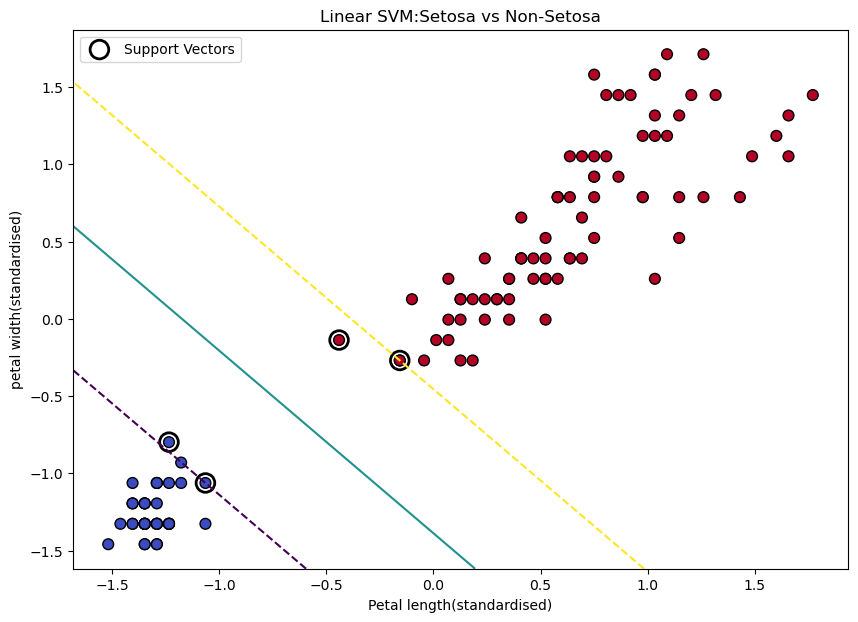

In [26]:
plt.figure(figsize=(10,7))
plt.scatter(
    x_train_scaled[:,0],
    x_train_scaled[:,1],
    c=y_train,
    s=60,
    cmap='coolwarm',
    edgecolors='k'
)
ax=plt.gca()
xlim=ax.get_xlim()
ylim=ax.get_ylim()
xx=np.linspace(xlim[0],xlim[1],200)
yy=np.linspace(ylim[0],ylim[1],200)
YY,XX=np.meshgrid(yy,xx)
xy=np.vstack([XX.ravel(),YY.ravel()]).T
Z=linear_svm.decision_function(xy)
Z=Z.reshape(XX.shape)
ax.contour(XX,YY,Z,
           levels=[-1,0,1],
           linestyles=['--','-','--']
          )
ax.scatter(linear_svm.support_vectors_[:,0],
           linear_svm.support_vectors_[:,1],
           s=180,
           facecolors='none',
           edgecolors='black',
           linewidths=2,
           label='Support Vectors'
          )
plt.xlabel("Petal length(standardised)")
plt.ylabel("petal width(standardised)")
plt.title("Linear SVM:Setosa vs Non-Setosa")
plt.legend()
plt.show()

In [27]:
x_full=iris.data
y_full=iris.target
x_train_full,x_test_full,y_train_full,y_test_full=train_test_split(
    x_full,
    y_full,
    test_size=0.20,
    random_state=42,
    stratify=y_full
)
scaler_full=StandardScaler()
x_train_full=scaler_full.fit_transform(x_train_full)
x_test_full=scaler_full.transform(x_test_full)

In [31]:

models = {
"Linear": SVC(kernel="linear", C=1.0),
"Polynomial": SVC(kernel="poly", degree=3, C=1.0),
"RBF": SVC(kernel="rbf", C=1.0, gamma="scale")
}

results = {}

for name, model in models.items():
   model.fit(x_train_full, y_train_full)

   y_pred = model.predict(x_test_full)
   accuracy = accuracy_score(y_test_full, y_pred)
   results[name] = accuracy

   print(f"\n{name} Kernel")
   print("-" * 30)
   print("Accuracy:", accuracy)

   print(classification_report(
     y_test_full,
     y_pred,
     target_names=iris.target_names
    ))




Linear Kernel
------------------------------
Accuracy: 1.0
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Polynomial Kernel
------------------------------
Accuracy: 0.9
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.77      1.00      0.87        10
   virginica       1.00      0.70      0.82        10

    accuracy                           0.90        30
   macro avg       0.92      0.90      0.90        30
weighted avg       0.92      0.90      0.90        30


RBF Kernel
------------------------------
Accuracy: 0.9666666666666667
              precision    recall  f1-scor